 # Assignment on Substitution Ciphers
   **_Group Name: QuantumResisters_**

In [19]:
# import modules
import matplotlib.pyplot as plt
import operator
import pickle

## Introduction

As we embark on the course of data security, we are introduced to the methods of secure communication between two persons- popularly known as cryptography. Along with the understanding of the encryption algorithms, cryptanalysis techniques to break the cryptosystems are also explored. Before encountering modern encryption algorithms or ciphers, we are informed about two historical ciphers, **_Caesar Ciphers_**, and **_Substitution Ciphers_**, that were used in the pre-digital era for encryption. 

In this assignment, we have performed two different attacks, a **_Brute-Force attack_** and a **_Frequency Analysis attack_** on given two encrypted texts to decrypt the plaintext which is encrypted with **_Caesar Cipher_** and **_Simple Substitution Cipher_** respectively. Besides finding the decrypted texts, we are also able to understand the underlying weakness of these historical ciphers for which they have become easily decodable using the attacks and thus obsolete in current cryptography practice. 

The initial part of the report consists of encryption, decryption methods for the caser cipher, and finally brute force attack on the given cipher text for finding plaintext using Python programming language along with a brief outline of the backend theory. The latter part of the report explains the simple substitution cipher and its encryption and decryption methods along with a frequency analysis attack on the provided encrypted text to retrieve the plaintext.

## Caesar Cipher

**_Caesar Cipher_** is one of the primitive ciphers which is named after Julius Caesar due to its alleged use in his military practice. This cipher works on the encryption of text where each letter of the message (text needed to be hidden) is replaced with another letter at a certain number of positions (named as **_Key_**) in the alphabet.**$^{[1-4]}$** For example, **_“A”_** becomes **_“G”_** with a shift of **_6_** where we consider marking the positions of letters in the alphabet starting from 0 for A to 25 for Z. Thus the word **_“ASSIGNMENT"_** becomes **_“GYYOMTSKTZ”_** as ciphertext (encrypted text) with a key (shift) of 6. Here the plaintext x and ciphertext y both are a text of n letters. Whereas the **key space K is 25** as we have only 25 fixed choices of shifting from the number of letters in the alphabet (26). The shift of 0 is nullified as it returns the same text of plaintext. The limited and small set of keys is the prime weakness of this cipher which is easily decodable using a **_Brute-Force attack_** which is described in later section.

### Encryption

In [160]:
def caesar_encrypt(plaintext, shift=0):
    ''' Encrypt `plaintext` (str) as a caesar cipher with a given `shift` (int) 
    '''
    # code here
    letters = "abcdefghijklmnopqrstuvwxyz"
    ciphertext = ""

    for char in plaintext:
        if char.isalpha():
            uppercase = char.isupper()
            char = char.lower()
            position = letters.find(char)
            new_position = position + shift
            new_char = letters[new_position]
            if uppercase:
                new_char = new_char.upper()
            ciphertext += new_char
        else:
            ciphertext += char
            
    return ciphertext

In [ ]:
# code snippet to test the implementation of the encryption function
plaintext = 'hello!' 
ciphertext = caesar_encrypt(plaintext, shift=4)

print(plaintext, '->', ciphertext) # expected output 'hello! -> lipps!'

### Decryption

In [156]:
def caesar_decrypt(ciphertext, shift=0):
    ''' Decrypt `ciphertext` (str) as a caesar cipher with a given `shift` (int) 
    '''
    # code here
    letters = "abcdefghijklmnopqrstuvwxyz"
    plaintext = ""

    for char in ciphertext:
        if char.isalpha():
            uppercase = char.isupper()
            char = char.lower()
            position = letters.find(char)
            new_position = (position - shift) % 26
            new_char = letters[new_position]
            if uppercase:
                new_char = new_char.upper()
            plaintext += new_char
        else:
            plaintext += char
            
    return plaintext

In [ ]:
# code snippet to test the implementation of the decryption function
ciphertext = 'lipps!' # 'hello!' encoded with shift=4
plaintext = caesar_decrypt(ciphertext, shift=4)

print(ciphertext, '->', plaintext)  # expected output 'lipps! -> hello!'

### Ciphertext

In [1]:
with open(file='ciphertext_caesar.txt', mode='r') as f:
    ciphertext = f.read()

### Brute Force Attack

As mentioned in earlier section the **_small key space_** makes Caesar Cipher vulnerable to **_ciphertext-only attack_**. Since the attacker will be aware of the encryption method as **_“Caesar cipher”_** because of _Kerckhoff ’s principle_, which states the encryption protocol and all about the encryption method should be in public except only the key to be hideous.$^{[1]}$ Therefore, the attacker just needs to check with all possible keys from 1 to 25 in cipher text until getting a legible meaningful English text.$^{[1-3]}$.This is popularly known as a **_Brute-Force attack_** or exhaustive key search method. So, in task 1 of this assignment, we only need to check a maximum of 25 times to make a successful Brute-Force attack on the given cipher text. We have been able to find out the plaintext which is about the city of Rome after 17 attempts with the shift of 18.

In [2]:
def caesar_decrypt(ciphertext, shift=0):
    letters = "abcdefghijklmnopqrstuvwxyz"
    decrypted_text = ""

    for char in ciphertext:
        if char.isalpha():
            uppercase = char.isupper()
            char = char.lower()
            position = letters.find(char)
            new_position = (position - shift) % 26
            new_char = letters[new_position]
            if uppercase:
                new_char = new_char.upper()
            decrypted_text += new_char
        else:
            decrypted_text += char

    return decrypted_text




In [ ]:
shift = 18
plaintext = caesar_decrypt(ciphertext, shift)
print(f"Decrypted text: {plaintext}")

## Simple Substitution Cipher

A **_simple substitution cipher_** is another historical cipher like Caesar cipher where the encryption function follows the method of replacing each letter of the plaintext.$^{[1-4]}$ But the major difference is the Key. Here each letter is replaced with another letter of the alphabet in random shuffling cum the key is now any _bijective mapping_ between the letters. For example, if we implement the mapping of _{'B': 'M', 'O': 'S', 'K': 'L', 'E': 'V', 'P': 'D', 'R': 'Z'}_ to the plaintext **_“BOOKKEEPER”_** then the encrypted text will be **_“MSSLLVVDVZ”_**. Unlike the Caeser cipher, here no fixed key is incorporated for encryption. This solves the major drawback of Caesar Cipher which is the small keyspace. Here the keyspace is now enlarged to **26!** Or $10^{27}$ resulting in practically unfeasible to break the ciphertext using a Brute-Force attack. However, still this encryption method is dated and counted as historical cipher due to its weakness of leaking information from plain text itself. The attacker can eventually launch the **_Frequency Analysis attack_** which is described in the later section. 

### Encryption

In [16]:
def substitution_encrypt(plaintext, mapping):
    ''' Encrypt `ciphertext` (str) as a simple substitution cipher with a given 
        `mapping` (??) from plaintext letters to ciphertext letters '''
    # code here
    ciphertext = ""
    for character in plaintext:
        if character.isalpha():
            is_upper = character.isupper()
            character = character.lower()
            if character in mapping:
                encrypted_char = mapping[character]
                if is_upper:
                    encrypted_char = encrypted_char.upper()
                ciphertext += encrypted_char
            else:
                ciphertext += character
        else:
            ciphertext += character
    return ciphertext

In [ ]:
# code snippet to test the implementation of the encryption function
plaintext = 'hello!'
mapping = {'h': 'a', 'e': 'p', 'l': 'w', 'o': 'q'}

ciphertext = substitution_encrypt(plaintext, mapping)

print(plaintext, '->', ciphertext) # expected output 'hello! -> apwwq!'

### Decryption

In [1]:
def substitution_decrypt(ciphertext, mapping):
    # code here
    decrypted_text = ""
    for character in ciphertext:
        if character.isalpha():
            is_upper = character.isupper()
            character = character.lower()
            decrypted_char = character
            for plain_char, cipher_char in mapping.items():
                if cipher_char == character:
                    decrypted_char = plain_char
                    break
            if is_upper:
                decrypted_char = decrypted_char.upper()
            decrypted_text += decrypted_char
        else:
            decrypted_text += character
    return decrypted_text

In [ ]:
# code snippet to test the implementation of the decryption function
mapping = {'h': 'a', 'e': 'p', 'l': 'w', 'o': 'q'}  # previous mapping 
ciphertext = 'apwwq!'

plaintext = substitution_decrypt(ciphertext, mapping)

print(ciphertext, '->', plaintext)  # expected output 'apwwq! -> hello!'

### Ciphertext

In [20]:
with open(file='ciphertext_simple.txt', mode='r') as f:
    ciphertext = f.read()

### Frequency Analysis Attack

As a fixed one-to-one mapping is used for encryption in a Substitution Cipher, the attacker attempts to make a guess of the plaintext observing the ciphertext. Evidently, the attacker will eventually get the obvious hint of a repetition of letters in ciphertext that will map to the same plaintext letter. By observing the frequency of a single letter in the ciphertext and comparing it with the frequency of English letter distribution, the attacker will eventually launch a cryptanalysis method called the frequency analysis attack.$^{[1-4]}$ For instance, if we take the earlier example of _"BOOKKEEPER"_ where by seeing the ciphertext _“MSSLLVVDVZ”_, we can assume of most repeated ciphertext letter _"V"_ to be mapped with plaintext letter _"E"_.

It is observed from *Figure 1* that **_"E"_** is the most used letter in any English text followed by _"T", "A", "O"_, etc and the least used letters are _"Z", "Q", "X"_, etc. So, there is a strong possibility to map the most frequent letter of ciphertext to the plaintext letter "E" and so on. By implementing this mapping, the ciphertext will eventually become more predictable. Also, several hints can be further retrieved from the ciphertext. For example, if there is a single independent repetitive letter throughout the ciphertext, the possibility of that letter being mapped in plaintext is restricted mostly to "A" or "I". Subsequently, the most common two-letter combinations (bigram) and three-letter combinations (trigram) that are used in the English language such as "AN", "AS", "IS", "IF", "IT", "THE", "AND", etc can be matched with the recurring bigrams and trigrams of the encrypted text. Using these trial-and-error methods, the attacker will find the exact mapping cum the key to decipher the ciphertext sooner or later.$^{[1-3]}$ 

The similar method we have incorporated here in task 2 of the assignment where we have plotted the frequency of letters in ciphertext in ascending order and have found **_"m"_** as the most used letter in ciphertext followed by "g", "v", "b" etc. To start with our iteration, we have mapped **_"m"_** _to_ **_"e"_**, _**"g"** to **"t"**_. With this initial mapping, some of the words in ciphertext have become somewhat familiar like the repetitive trigram **_"gcm"_** changed to **_"tce"_** which signifies **_"c"_** can be mapped to **_"h"_** to get “the” as plaintext. Similarly independent recurring letter like **_"b"_** is mapped to **_"a"_**. Now, by taking some bigrams like **_vf, vb, vl_**, we can assume **_"v"_** to be mapped to **_"i"_** as most of the common bigrams start with the letter "a" or "i" and as already "a" have been mapped that leaves us with only "i". Eventually, We have carried out further iterations to guess the same repetitive part of words present in ciphertext like **_"pvycms--"_**, **_"--gmng"_** which has been transformed after previous mappings to **_"ciyher"_**, **_"tent"_**  which can be inferred as **_"cipher"_**, **_"text"_**. We repeat this process several times until we get most of the correct mappings and with further trials and shuffling, we have finally deciphered the given ciphertext to plaintext which is a writing about substitution cipher.


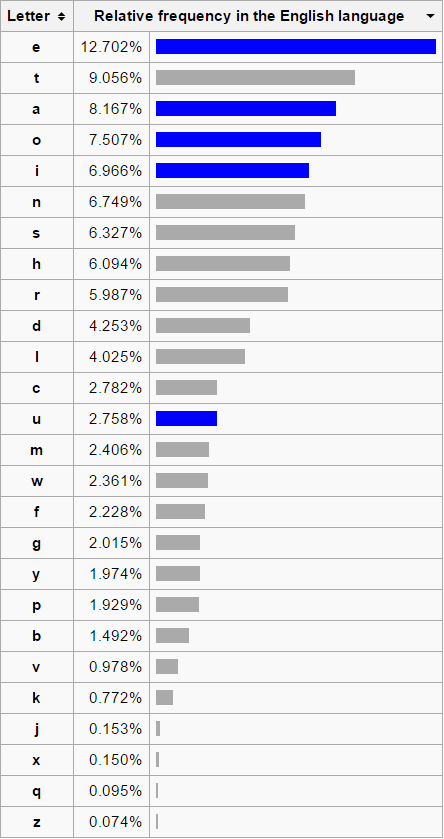

***Figure 1**:__Relative frequency of letters in the English language__ (courtesy: https://case.edu/artsci/math/singer/Sage/alphabetfreq.shtml)*

#### English Letters Distribution

In [7]:
# function to infer the letter distribution from a text
def letter_distribution(text):
    distribution = {}
    total_char = 0
    for char in text:
        if char.isalpha():
            char = char.lower()
            if char in distribution:
                distribution[char] += 1
            else: 
                distribution[char] = 1
        total_char += 1    
    for char in distribution:
        distribution[char] = round(distribution[char] / total_char,3)
    return distribution

In [ ]:
# code snippet to test the implementation of `letter_distribution`
text = 'hello world'

letter_distribution(text)
# expected ouput: 
# {'d': 0.1, 'e': 0.1, 'h': 0.1, 'l': 0.3, 'o': 0.2, 'r': 0.1, 'w': 0.1, ...}

In [ ]:
# load text
print (ciphertext)

In [ ]:
# estimate the English letters distribution 
text = ciphertext
letter_distribution(text)

In [ ]:
# plot the English letter distribution
letter_distribution = {
    'v': 0.063, 'f': 0.051, 'p': 0.029, 's': 0.05, 'e': 0.014,
    'y': 0.025, 'g': 0.075, 'd': 0.047, 't': 0.012, 'b': 0.063,
    'c': 0.039, 'l': 0.054, 'x': 0.023, 'o': 0.018, 'm': 0.102,
    'k': 0.019, 'j': 0.027, 'r': 0.015, 'u': 0.01, 'w': 0.036,
    'n': 0.004, 'q': 0.005, 'a': 0.007, 'h': 0.002, 'i': 0.001
}
sorted_dist = dict(sorted(letter_distribution.items(), key = operator.itemgetter(1), reverse=True))
letters = list(sorted_dist.keys())
Probability_Value = list(sorted_dist.values())

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

ax.barh(letters, Probability_Value, height=0.6)
ax.set_xlim((min(Probability_Value), max(Probability_Value),))
ax.set_xticks([0.00, 0.02, 0.04, 0.06, 0.08, 0.10])
ax.set_title("Letter Distribution Histogram")
ax.set_ylabel('Letters')
ax.set_xlabel('Probability_Value')

In [14]:
# store the distribution as a pickle file
with open(file='letter_distribution.pkl', mode='wb') as f:
    pickle.dump(letter_distribution, f)

with open(file='letter_distribution.pkl', mode='rb') as f:
    letter_distribution2 = pickle.load(f)


#### Perform attack

In [23]:
# perform Frequency analysis attack
def substitution_decrypt(ciphertext, mapping):
    decrypted_text = ""
    for character in ciphertext:
        if character.isalpha():
            is_upper = character.isupper()
            character = character.lower()
            decrypted_char = character
            for plain_char, cipher_char in mapping.items():
                if cipher_char == character:
                    decrypted_char = plain_char
                    break
            if is_upper:
                decrypted_char = decrypted_char.upper()
            decrypted_text += decrypted_char
        else:
            decrypted_text += character
    return decrypted_text
mapping = {'e': 'm', 't': 'g', 'a': 'b', 'i': 'v', 
           's': 'l', 'n': 'f', 'r': 's', 'o': 'd', 
           'h': 'c', 'l': 'w', 'c': 'p', 'd': 'j', 
           'p': 'y', 'u': 'x', 'm': 'k', 'b': 'o', 
           'f': 'r', 'y': 'e', 'g': 't', 'w': 'u', 
           'v': 'a', 'k': 'q', 'x': 'n', 'q': 'h', 
           'z': 'i', 'j': 'z'}

plaintext = substitution_decrypt(ciphertext, mapping)


In [ ]:
# print mapping
print (mapping)

In [ ]:
# print decrypted plaintext
print (plaintext)

## Affine cipher

### Encryption

In [ ]:
from math import gcd

In [ ]:
def affine_encrypt(plaintext, a, b):
    ''' Encrypt `plaintext` (str) as an affine cipher with given `a` and `b` 
    '''
    return ciphertext

In [ ]:
plaintext = 'hello world!'
a, b = 3, 1

ciphertext = affine_encrypt(plaintext, a, b)
print(plaintext, '->', ciphertext) # expected output 'hello world! -> wniir praik!'

### Decryption

In [ ]:
def affine_decrypt(ciphertext, a, b):
    ''' Decrypt `ciphertext` (str) as an affine cipher with given `a` and `b` 
    '''
    return plaintext

In [ ]:
ciphertext = 'wniir praik!'
a, b = 3, 1

plaintext = affine_decrypt(ciphertext, a, b)
print(ciphertext, '->', plaintext) # expected output 'wniir praik! -> hello world!'

### Ciphertext

In [ ]:
# Load ciphertext

### Breaking Cipher

## Conclusion

Two historical ciphers, **_"Caesar Cipher"_** and **_"Simple Substitution Cipher"_** are discussed, and using programming two different cryptanalysis methods are probed to decode the given encrypted texts. It is observed that both ciphers are highly susceptible to attacks but **Caesar Cipher** is arguably the weakest one. A minuscule keyspace of a mere 25 possible keys results in a requirement of only a maximum of 25 guesses to decode the ciphertext. This attack in cryptology is known as **_"Brute-Force attack"_**.  Eventually, with our programming, we have also found it easier to crack with the defined **_"caesar_decrypt"_** decryption function as we have tried 17 keys and at the **_18th_** key when we obtain the encrypted text about the city of Rome. On the contrary, as the keyspace is now as large as $10^{27}$ in the case of **_Simple Substitution Cipher_** it is found to be impossible to follow the same approach of Brute-Force attack. 

Although the simple substitution cipher is found to be more complex than the Caeser cipher, a prominent flaw is found where it can be guessed the plaintext letter by seeing the ciphertext. Due to the use of fixed bijective mapping between the letters in the alphabet, repetitions occur in ciphertext. By finding the recurring letters in ciphertext with their occurrence frequency and eventually comparing them with the frequency of letters in any English text we have been able to launch another attack called **_"Frequency Analysis attack"_**. A decryption function **_"substitution_decrypt"_** is used and finally, after several iterations, we have found the correct mapping along with the decrypted text. 

Needless to say, both the historical cipher systems are now obsolete in this crypto-digital era but to understand the basics of cryptology these two ciphers are still an obvious choice to start with. With this assignment along with the theory, we are hopefully able to grasp the rudiments of cryptanalysis methods. Our work on both tasks has successfully covered all the requirements of this assignment. However, we are still striving to construct a programming method in which the required key _(shift value for Caesar Cipher and mapping for Substitution Cipher)_ will be obtained autonomously instead of our trial-and-error method.


## References

1.	Smart, N. P. Cryptography: An Introduction. vol. 3 (McGraw-Hill New York, 2003).

2.	Rubinstein-Salzedo, S. Cryptography. vol. 260 (Springer, 2018).

3.  Classnotes from theory class of "Elements of Data Security".

4.  Practical Cryptography – Classical Ciphers URL: https://practicalcryptography.com/ciphers/caesar-cipher/
